# Functions

In [1]:
import dill
#dill.dump_session('Simulation_example_IL_assumption.pkl')
dill.load_session('Simulation_example_IL_assumption.pkl')


In [3]:
# generating a nonempty 2D feasible set
import numpy as np
import scipy


from scipy.optimize import linprog
# Creates a random feasible set by solving an LP
def generate_random_feasible_set(dimensions, num_constraints):
    # Generate random coefficients for the inequality constraints
    A = np.random.randint(-10, 10, size=(num_constraints, dimensions))
    #A = np.random.randint(num_constraints, dimensions)
    # Generate random right-hand side values for the inequality constraints
    b = np.random.randint(-5, 5, size=num_constraints)

    #b = np.random.rand(num_constraints)

    # Create the bounds for each variable (bounded feasible set)
    bounds = [(0, 10) for _ in range(dimensions)]

    # Solve the linear programming problem to find a feasible solution
    result = linprog(c=[-1] * dimensions, A_ub=A, b_ub=b, bounds=bounds)
    
    # Check if the feasible set is non-empty
    if result.success:
        return A, b, bounds
    else:
        return generate_random_feasible_set(dimensions, num_constraints)

if __name__ == "__main__":
    dimensions = 2
    min_constraints = 2
    max_constraints = 4
    
    num_constraints = np.random.randint(min_constraints, max_constraints+1)

    A, b, bounds = generate_random_feasible_set(dimensions, num_constraints)

    print("Generated Feasible Set:")
    print("Inequality Constraints (ax >= b):")
    print(A)
    print("RHS Values (b):")
    print(b)
    print("Variable Bounds:")
    print(bounds)


Generated Feasible Set:
Inequality Constraints (ax >= b):
[[-2  4]
 [ 1  4]]
RHS Values (b):
[-1  4]
Variable Bounds:
[(0, 10), (0, 10)]


In [4]:
import numpy as np
from scipy.optimize import linprog

MAX_ATTEMPTS = 100

def generate_random_feasible_set(dimensions, num_constraints, attempt=1):
    if attempt > MAX_ATTEMPTS:
        raise RuntimeError("Maximum attempts reached without finding a feasible set.")

    A = np.random.randint(-10, 10, size=(num_constraints, dimensions))
    b = np.random.randint(-5, 5, size=num_constraints)
    bounds = [(0, 10) for _ in range(dimensions)]
    result = linprog(c=[-1] * dimensions, A_ub=A, b_ub=b, bounds=bounds)

    if result.success:
        return A, b, bounds
    else:
        return generate_random_feasible_set(dimensions, num_constraints, attempt + 1)

# Example usage
if __name__ == "__main__":
    dimensions = 2
    min_constraints = 2
    max_constraints = 2
    
    num_constraints = np.random.randint(min_constraints, max_constraints+1)

    A, b, bounds = generate_random_feasible_set(dimensions, num_constraints)

    print("Generated Feasible Set:")
    print("Inequality Constraints (ax >= b):")
    print(A)
    print("RHS Values (b):")
    print(b)
    print("Variable Bounds:")
    print(bounds)



Generated Feasible Set:
Inequality Constraints (ax >= b):
[[-7 -8]
 [-6  8]]
RHS Values (b):
[-4 -2]
Variable Bounds:
[(0, 10), (0, 10)]


In [5]:
import numpy as np

def is_feasible_point(A, b, x):
    # Check if the point x satisfies all constraints Ax <= b
    return np.all(np.dot(A, x) <= b)

def generate_random_feasible_point(A, b):
    num_variables = A.shape[1]
    # Generate a random point in the feasible range of variables
    x = np.random.uniform(-10, 10, size=num_variables)
    #x1 = np.random.uniform(-10, 10)
    #x2 = np.random.uniform(-10, 10)
    #x = [x1,x2]

    # Check if the randomly generated point is feasible
    #if is_feasible_point(A, b, x):
    return x

# Generate a random feasible point for the constrained set Ax <= b
feasible_point = generate_random_feasible_point(A, b)
print("Random Feasible Point:", feasible_point)


Random Feasible Point: [-0.72134033  0.23161571]


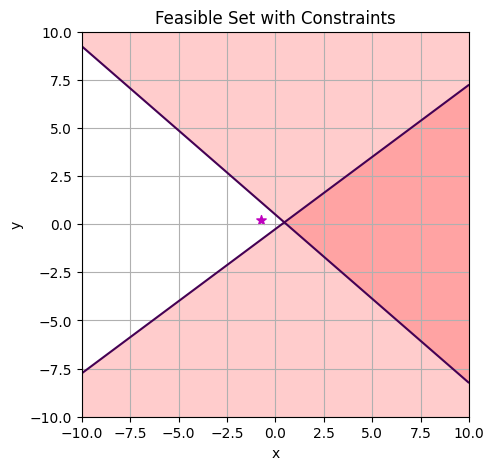

In [6]:
# plotting the feasible set
import numpy as np
import matplotlib.pyplot as plt

def plot_constraints(A, b, bounds):
    # Generate points in the feasible region
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    plt.figure(figsize=(5, 5))
    # Plot each inequality constraint as a filled contour plot
    for i in range(A.shape[0]):
        Z = A[i][0] * X + A[i][1] * Y - b[i]
        plt.contourf(X, Y, Z, levels=[-1e10, 0], colors='r', alpha=0.2)
        plt.contour(X, Y, Z, levels=[0])


    # Plot the bounds as a rectangle
    #rectangle = plt.Rectangle((bounds[0][0], bounds[1][0]), bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], edgecolor='b', fill=False)
    #plt.gca().add_patch(rectangle)
    plt.scatter(feasible_point[0], feasible_point[1], color='m', marker='*', s=50, label='Optimal Solution')

    # Set plot labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Feasible Set with Constraints')

    # Show the plot
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    # Replace these with the constraints from the generated feasible set
    bounds = [(-10, 10), (-10, 10)]  # Example bounds for x and y
    #A = a
    plot_constraints(A, b, bounds)


In [2]:
import os
import gurobipy as gp
e = gp.Env(empty=True)
e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
e.setParam('LICENSEID', 862033)
e.start()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu


<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=862033>

In [8]:
import os
import gurobipy as gp
import dill
from gurobipy import GRB
def IO(A,b,X):
    #print ('IL started')
    m1 = A.shape[0]
    n = A.shape[1]
    K = X.shape[0]
    AT = A.T
    num_var = 2 * K * n + 3 * n + m1
    e = gp.Env(empty=True)
    e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
    e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
    e.setParam('LICENSEID', 862033)
    e.start()
    m = gp.Model("IO",env=e)
    #m.Params.timeLimit = 10.0
    m.Params.OutputFlag = 0
    # Create variables
    e = m.addVars(K,n,  lb=-GRB.INFINITY, name = 'e')
    t = m.addVars(K,n,  lb=-GRB.INFINITY, name = 't')
    c = m.addVars(n,  lb=-GRB.INFINITY, name = 'c')
    y = m.addVars(m1,  lb=-GRB.INFINITY, name = 'y')
    d = m.addVars(n,  lb=-GRB.INFINITY, name = 'd')
    z = m.addVars(n, lb=-GRB.INFINITY, name = 'z')


    # Set objective:
    m.setObjective(gp.quicksum(t[k,i] for k in range (K) for i in range(n)), GRB.MINIMIZE)
    # Constraints 
    for k in range (K):
        m.addConstrs(t[k,i] >= e[k,i] for i in range(n))
        m.addConstrs(t[k,i] >= -e[k,i] for i in range(n))
        m.addConstrs(X[k,i] - e[k,i]  == z[i] for i in range(n))
    for j in range(m1):
        m.addConstr(gp.quicksum(A[j,i] * z[i] for i in range(n)) <= b[j])
    for i in range(n):
        m.addConstr(gp.quicksum(y[j] * A[j,i] for j in range(m1)) == c[i])    
    m.addConstrs(y[j] >= 0 for j in range(m1))
    m.addConstr(gp.quicksum(c[j] * z[j] for j in range(n)) == gp.quicksum(b[i] * y[i] for i in range(m1)))
    #for i in range(n):
    #    m.addConstr(d[i] == gp.abs_(c[i]))
    #m.addConstr(gp.quicksum(d[i] for i in range(n)) == 1) 
    m.addConstr(gp.quicksum(y[j]  for j in range(m1)) == 1)
    #m.addConstr(z[14] == 0) #no_egg_omelette_substitute
    #m.addConstr(z[26] == 0) #no_meat_substitute
    m.params.NonConvex = 2   
    m.optimize()
    #print("IL Status:", m.status)
    vars = m.getVars()
    #for i in range (n):
    #    print (vars [num_var -1 -(n-1-i)])
#     n = A.shape[1]
    Z = np.zeros (n)
    C = np.zeros (n)
    feas = (m.status == GRB.OPTIMAL)
    if feas:
        count = 0
        for v in z.values():
            Z[count] = v.X
            count += 1
        count = 0
        for v in c.values():
            C[count] = v.X
            count += 1
        m.dispose()
        return Z, C
    else:
        m.dispose()
        return np.NaN, np.NaN

In [9]:
import os
def IOm(A,b,X,m_index):
    m1 = A.shape[0]
    n = A.shape[1]
    K = X.shape[0]
    AT = A.T
    num_var = 2 * K * n + 3 * n + m1
    e = gp.Env(empty=True)
    e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
    e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
    e.setParam('LICENSEID', 862033)
    e.start()
    m = gp.Model("IO",env=e)
    #m.Params.timeLimit = 20.0
    m.Params.OutputFlag = 0
    # Create variables
    e = m.addVars(K,n,  lb=-GRB.INFINITY, name = 'e')
    t = m.addVars(K,n,  lb=-GRB.INFINITY, name = 't')
    c = m.addVars(n,  lb=-GRB.INFINITY, name = 'c')
    y = m.addVars(m1,  lb=-GRB.INFINITY, name = 'y')
    d = m.addVars(n,  lb=-GRB.INFINITY, name = 'd')
    z = m.addVars(n, lb=-GRB.INFINITY, name = 'z')


    # Set objective:
    m.setObjective(gp.quicksum(t[k,i] for k in range (K) for i in range(n)), GRB.MINIMIZE)
    # Constraints 
    for k in range (K):
        m.addConstrs(t[k,i] >= e[k,i] for i in range(n))
        m.addConstrs(t[k,i] >= -e[k,i] for i in range(n))
        m.addConstrs(X[k,i] - e[k,i]  == z[i] for i in range(n))
    for j in range(m1):
            m.addConstr(gp.quicksum(A[j,i] * z[i] for i in range(n)) <= b[j])
                
    for j in range(m1):
        m.addConstr(gp.quicksum(A[j,i] * z[i] for i in range(n)) <= b[j])
    m.addConstr(gp.quicksum(A[m_index,i] * z[i] for i in range(n)) == b[m_index])
    m.params.NonConvex = 2 
    m.optimize()        
    print("IO Status:", m.status)
    vars = m.getVars()
    #for i in range (n):
    #    print (vars [num_var -1 -(n-1-i)])
#     n = A.shape[1]
    Z = np.zeros (n)
    C = np.zeros (n)
    feas = (m.status == GRB.OPTIMAL)
    if feas:
        count = 0
        for v in z.values():
            Z[count] = v.X
            count += 1
        objective_value = m.objVal
        m.dispose()
        return Z, objective_value
    else:
        m.dispose()
        return np.NaN, np.NaN

In [10]:
Z_IL, C_IL = IO(A,b,np.array([feasible_point,feasible_point]))


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu


In [12]:
#choose random cost vector and solve a max lin problem
def random_cost_vector(A):
    num_constraints, num_variables = A.shape
    return A[np.random.randint(num_constraints)]

def linear_programming_maximize(cost_vector, A, b):
    from scipy.optimize import linprog

    c = -cost_vector  # Linear programming uses minimization, so negate the cost vector for maximization
    result = linprog(c, A_ub=A, b_ub=b)
    return result.x  # Negate the result back to get the maximization value

def linear_programming_maximize_simplex(cost_vector, A, b):
    from scipy.optimize import linprog

    c = -cost_vector  # Linear programming uses minimization, so negate the cost vector for maximization
    variable_bounds = [(-10, 10) for _ in range(A.shape[1])]
    #variable_bounds = [(-10, 10), (-10, 10)]
    result = linprog(c, A_ub=A, b_ub=b, method = 'simplex',bounds=variable_bounds )
    return result.x  # Negate the result back to get the maximization value

# Randomly choose one of the left-hand side vectors as the cost vector
cost_vector = random_cost_vector(A)
cost_vector = np.array([-1,-0.2])

# Solve the linear maximization problem
optimal_solution = linear_programming_maximize_simplex(cost_vector, A, b)

print("Cost Vector:", cost_vector)
print("Optimal Solution:", optimal_solution)

Cost Vector: [-1.  -0.2]
Optimal Solution: [0.46153846 0.09615385]


/tmp/ipykernel_966333/3648782748.py:19: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  result = linprog(c, A_ub=A, b_ub=b, method = 'simplex',bounds=variable_bounds )


In [14]:

magnitude = np.linalg.norm(cost_vector)

# Perform size normalization
cost_vector = cost_vector / magnitude

print("Size-normalized Array:", cost_vector)

Size-normalized Array: [-0.98058068 -0.19611614]


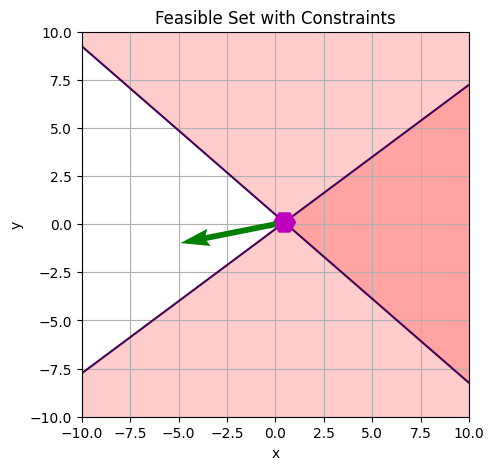

In [15]:
# plotting the feasible set
import numpy as np
import matplotlib.pyplot as plt

def plot_constraints(A, b, bounds):
    # Generate points in the feasible region
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    plt.figure(figsize=(5, 5))
    # Plot each inequality constraint as a filled contour plot
    for i in range(A.shape[0]):
        Z = A[i][0] * X + A[i][1] * Y - b[i]
        plt.contourf(X, Y, Z, levels=[-1e10, 0], colors='r', alpha=0.2)
        plt.contour(X, Y, Z, levels=[0])


    # Plot the bounds as a rectangle
    #rectangle = plt.Rectangle((bounds[0][0], bounds[1][0]), bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], edgecolor='b', fill=False)
    #plt.gca().add_patch(rectangle)
    # Plot the cost vector
    
    # Plot the optimal solution
    plt.scatter(optimal_solution[0], optimal_solution[1], color='m', marker='H', s=250, label='Optimal Solution',zorder = 2)
      # Set the size of the figure

    # Set plot labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Feasible Set with Constraints')

    # Show the plot
    plt.grid(True)
    origin = [0, 0]
    plt.quiver(*origin, cost_vector[0], cost_vector[1], angles='xy', scale_units='xy', scale=0.2, width=0.015, color='g', zorder=2, label='Cost Vector')
    plt.show()

if __name__ == "__main__":
    # Replace these with the constraints from the generated feasible set
    bounds = [(-10, 10), (-10, 10)]  # Example bounds for x and y
    #A = a
    plot_constraints(A, b, bounds)


In [17]:
#generate a random point on the plane
def generate_random_point(bounds):
    # bounds should be a list or tuple with four elements [x_min, x_max, y_min, y_max]
    x_min, x_max, y_min, y_max = bounds
    x = np.random.uniform(x_min, x_max)
    y = np.random.uniform(y_min, y_max)
    return x, y

# Example usage:
bounds = [-10, 10, -10, 10]  # Define the bounds [x_min, x_max, y_min, y_max]
random_point = generate_random_point(bounds)
print("Random Point:", random_point)


Random Point: (4.114780649535351, -3.625113584816651)


In [16]:
optimal_solution 

array([0.46153846, 0.09615385])

In [18]:
#generate noised observations
def generate_noisy_points(original_point, noise_scale=1):
    # original_point should be a tuple or list with two elements (x, y)
    x, y = original_point
    num_points = np.random.randint(2,8)
    noise_x = np.random.normal(loc=0, scale=noise_scale, size=num_points)
    noise_y = np.random.normal(loc=0, scale=noise_scale, size=num_points)
    noisy_points = [(x + noise_x[i], y + noise_y[i]) for i in range(num_points)]
    return noisy_points

# Example usage:
#original_point = random_point
original_point = optimal_solution

noisy_points = generate_noisy_points(original_point)
print("Original Point:", original_point)
print("Noisy Points:", noisy_points)


Original Point: [0.46153846 0.09615385]
Noisy Points: [(0.9202221553681885, 0.08454066104316349), (0.1277275990733015, 1.059374752677285), (-0.5785884155055909, -1.7145778595338268), (-0.16768843003187806, 0.1791407344340393), (0.4412258144825576, 0.4805486346187296), (0.42280437106675794, 0.06268411004108154)]


In [19]:
def generate_noisy_points_high_dimension(original_point, noise_scale=1):
    # original_point should be a tuple, list, or numpy array with any number of dimensions
    original_point = np.array(original_point)
    num_dimensions = original_point.shape[0]
    
    num_points = np.random.randint(4, 8)
    noise = np.random.normal(loc=0, scale=noise_scale, size=(num_points, num_dimensions))
    
    noisy_points = [original_point + noise[i] for i in range(num_points)]
    return noisy_points

# Example usage with a 2-dimensional point
noisy_points = generate_noisy_points_high_dimension(original_point, noise_scale=1.5)
print("Noisy Points:", noisy_points)

Noisy Points: [array([ 2.99603942, -1.88235118]), array([5.25642409, 1.19372356]), array([1.01443266, 0.15976039]), array([1.0282687 , 2.43352774]), array([0.8053632, 1.9271277])]


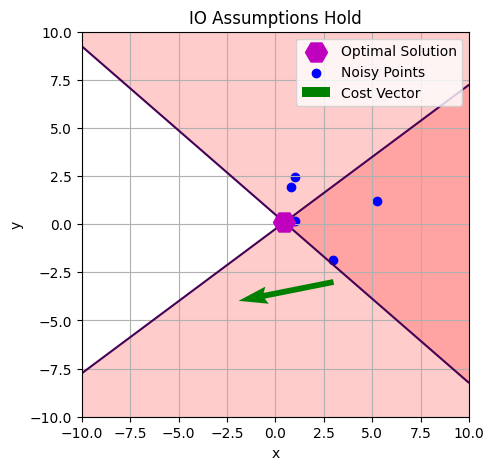

In [20]:
# plotting the feasible set
import numpy as np
import matplotlib.pyplot as plt

def plot_constraints(A, b, bounds,title = 'IO Assumptions Hold'):
    # Generate points in the feasible region
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    plt.figure(figsize=(5, 5))
    # Plot each inequality constraint as a filled contour plot
    for i in range(A.shape[0]):
        Z = A[i][0] * X + A[i][1] * Y - b[i]
        plt.contourf(X, Y, Z, levels=[-1e10, 0], colors='r', alpha=0.2)
        plt.contour(X, Y, Z, levels=[0])


    # Plot the bounds as a rectangle
    #rectangle = plt.Rectangle((bounds[0][0], bounds[1][0]), bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], edgecolor='b', fill=False)
    #plt.gca().add_patch(rectangle)

    # Plot the optimal solution
    plt.scatter(optimal_solution[0], optimal_solution[1], color='m', marker='H', s=250, label='Optimal Solution',zorder = 2)
      # Set the size of the figure
    x_vals, y_vals = zip(*noisy_points)
    plt.scatter(x_vals, y_vals, color='blue', label='Noisy Points')

    origin = [3, -3]
    plt.quiver(*origin, cost_vector[0], cost_vector[1], angles='xy', scale_units='xy', scale=0.2, width=0.015, color='g', zorder=2, label='Cost Vector')

        
    # Set plot labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    #plt.savefig(title + '2.png', dpi=300)
    #plt.savefig(title + '2.pdf')
    plt.legend(loc='best',  frameon=True)


    # Show the plot
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    # Replace these with the constraints from the generated feasible set
    bounds = [(-10, 10), (-10, 10)]  # Example bounds for x and y
    #A = a
    plot_constraints(A, b, bounds)


Cost Vector: [-7 -8]
Optimal Solution: [0.46153846 0.09615385]
Size-normalized Array: [-0.65850461 -0.75257669]
Noisy Points: [array([0.17165716, 0.12940182]), array([-0.96540225, -2.82091851]), array([ 0.04738757, -0.60604569]), array([ 0.5035131 , -1.37627575]), array([1.130721  , 1.39853156])]


/tmp/ipykernel_966333/3648782748.py:19: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  result = linprog(c, A_ub=A, b_ub=b, method = 'simplex',bounds=variable_bounds )


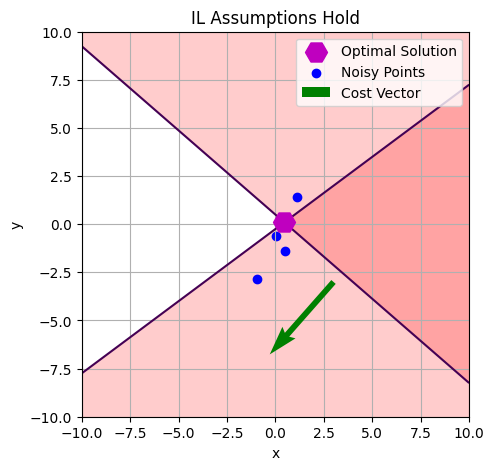

In [21]:
cost_vector = random_cost_vector(A)
#cost_vector = np.array([-1,-0.2])

# Solve the linear maximization problem
optimal_solution = linear_programming_maximize_simplex(cost_vector, A, b)

print("Cost Vector:", cost_vector)
print("Optimal Solution:", optimal_solution)

magnitude = np.linalg.norm(cost_vector)
# Perform size normalization
cost_vector = cost_vector / magnitude
print("Size-normalized Array:", cost_vector)

original_point = optimal_solution
noisy_points = generate_noisy_points_high_dimension(original_point, noise_scale=1)
print("Noisy Points:", noisy_points)

plot_constraints(A, b, bounds, title = 'IL Assumptions Hold')



Random Feasible Point: [8.01764503 3.37866461]
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Size-normalized Array: [-0.6  0.8]
Noisy Points: [array([6.01569541, 6.68421095]), array([9.28262012, 4.20991653]), array([5.77797161, 4.68175795]), array([7.12414743, 6.4321721 ])]


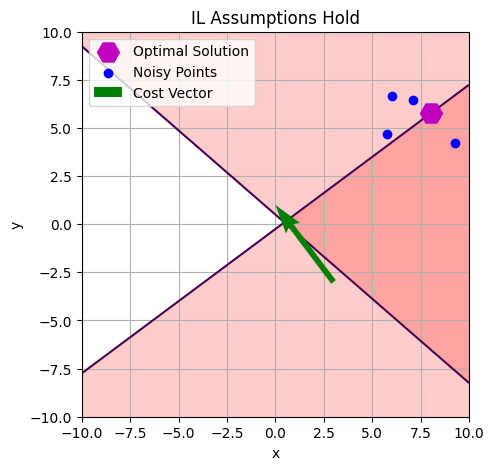

In [22]:
#IL Assumptions Hold
# Generate a random feasible point for the constrained set Ax <= b
feasible_point = generate_random_feasible_point(A, b)
print("Random Feasible Point:", feasible_point)

Z_IL, C_IL = IO(A,b,np.array([feasible_point,feasible_point]))
cost_vector = C_IL
optimal_solution = Z_IL

magnitude = np.linalg.norm(cost_vector)
# Perform size normalization
cost_vector = cost_vector / magnitude
print("Size-normalized Array:", cost_vector)

original_point = optimal_solution
noisy_points = generate_noisy_points_high_dimension(original_point, noise_scale=1.5)
print("Noisy Points:", noisy_points)

plot_constraints(A, b, bounds, title = 'IL Assumptions Hold')


In [23]:
import os
def OIO(A,b,X):
    m1 = A.shape[0]
    n = A.shape[1]
    K = X.shape[0]
    AT = A.T
    num_var = 2 * K * n + 3 * n + m1
    e = gp.Env(empty=True)
    e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
    e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
    e.setParam('LICENSEID', 862033)
    e.start()
    m = gp.Model("IO",env=e)
    #m.Params.timeLimit = 20.0
    m.Params.OutputFlag = 0
    # Create variables
    e = m.addVars(K,n,  lb=-GRB.INFINITY, name = 'e')
    t = m.addVars(K,n,  lb=-GRB.INFINITY, name = 't')
    c = m.addVars(n,  lb=-GRB.INFINITY, name = 'c')
    y = m.addVars(m1,  lb=-GRB.INFINITY, name = 'y')
    d = m.addVars(n,  lb=-GRB.INFINITY, name = 'd')
    z = m.addVars(K,n, lb=-GRB.INFINITY, name = 'z')


    # Set objective:
    m.setObjective(gp.quicksum(t[k,i] for k in range (K) for i in range(n)), GRB.MINIMIZE)
    # Constraints 
    for k in range (K):
        m.addConstrs(t[k,i] >= e[k,i] for i in range(n))
        m.addConstrs(t[k,i] >= -e[k,i] for i in range(n))
        m.addConstrs(X[k,i] - e[k,i]  == z[k,i] for i in range(n))
    for j in range(m1):
            for k in range (K):
                m.addConstr(gp.quicksum(A[j,i] * z[k,i] for i in range(n)) <= b[j])
    for i in range(n):
        m.addConstr(gp.quicksum(y[j] * A[j,i] for j in range(m1)) == c[i])    
    m.addConstrs(y[j] >= 0 for j in range(m1))
    for k in range(K):
        m.addConstr(gp.quicksum(c[j] * z[k,j] for j in range(n)) == gp.quicksum(b[i] * y[i] for i in range(m1)))
    #for i in range(n):
    #    m.addConstr(d[i] == gp.abs_(c[i]))
    #m.addConstr(gp.quicksum(d[i] for i in range(n)) == 1) 
    m.addConstr(gp.quicksum(y[j]  for j in range(m1)) == 1)
    #m.addConstr(z[14] == 0) #no_egg_omelette_substitute
    #m.addConstr(z[26] == 0) #no_meat_substitute
    m.params.NonConvex = 2   
    m.optimize()
    print("IO Status:", m.status)
    vars = m.getVars()
    #for i in range (n):
    #    print (vars [num_var -1 -(n-1-i)])
#     n = A.shape[1]
    Z = np.zeros ([K*n])
    C = np.zeros (n)
    feas = (m.status == GRB.OPTIMAL)
    if feas:
        count = 0
        for v in z.values():
            Z[count] = v.X
            count += 1
        count = 0
        for v in c.values():
            C[count] = v.X
            count += 1
        m.dispose()    
        return Z, C
    else:
        m.dispose()
        return np.NaN, np.NaN

In [24]:
cost_vector

array([-0.6,  0.8])

In [25]:
Z_IL, C_IL = IO(A,b,np.array(noisy_points))
C_IL

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu


array([-6.,  8.])

In [26]:
Z_IL

array([6.87474857, 4.90606143])

In [27]:
Z_IO,C_IO = OIO(A,b,np.array(noisy_points))
C_IO

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
IO Status: 2


array([-6.,  8.])

In [28]:
Z_IO_reshape = [(Z_IO[2*i], Z_IO[2*i+1]) for i in range(int(len(Z_IO)/2))]
Z_IO_reshape

[(6.0156959769217275, 4.261771982691054),
 (9.282619556483825, 6.71196466736268),
 (5.777972175157823, 4.083479131368111),
 (7.1241479948188084, 5.093110996113895)]

In [29]:
import os
def OIOm(A,b,X,m_index):
    m1 = A.shape[0]
    n = A.shape[1]
    K = X.shape[0]
    AT = A.T
    num_var = 2 * K * n + 3 * n + m1
    e = gp.Env(empty=True)
    e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
    e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
    e.setParam('LICENSEID', 862033)
    e.start()
    m = gp.Model("IO",env=e)
    #m.Params.timeLimit = 20.0
    m.Params.OutputFlag = 0
    # Create variables
    e = m.addVars(K,n,  lb=-GRB.INFINITY, name = 'e')
    t = m.addVars(K,n,  lb=-GRB.INFINITY, name = 't')
    c = m.addVars(n,  lb=-GRB.INFINITY, name = 'c')
    y = m.addVars(m1,  lb=-GRB.INFINITY, name = 'y')
    d = m.addVars(n,  lb=-GRB.INFINITY, name = 'd')
    z = m.addVars(K,n, lb=-GRB.INFINITY, name = 'z')


    # Set objective:
    m.setObjective(gp.quicksum(t[k,i] for k in range (K) for i in range(n)), GRB.MINIMIZE)
    # Constraints 
    for k in range (K):
        m.addConstrs(t[k,i] >= e[k,i] for i in range(n))
        m.addConstrs(t[k,i] >= -e[k,i] for i in range(n))
        m.addConstrs(X[k,i] - e[k,i]  == z[k,i] for i in range(n))
    for j in range(m1):
            for k in range (K):
                m.addConstr(gp.quicksum(A[j,i] * z[k,i] for i in range(n)) <= b[j])
                
    for j in range(m1):
        for k in range (K):
            m.addConstr(gp.quicksum(A[j,i] * z[k,i] for i in range(n)) <= b[j])
    for k in range (K):
        m.addConstr(gp.quicksum(A[m_index,i] * z[k,i] for i in range(n)) == b[m_index])
    m.params.NonConvex = 2 
    m.optimize()        
    print("IO Status:", m.status)
    vars = m.getVars()
    #for i in range (n):
    #    print (vars [num_var -1 -(n-1-i)])
#     n = A.shape[1]
    Z = np.zeros ([K*n])
    C = np.zeros (n)
    feas = (m.status == GRB.OPTIMAL)
    if feas:
        count = 0
        for v in z.values():
            Z[count] = v.X
            count += 1
        objective_value = m.objVal
        m.dispose()
        return Z, objective_value
    else:
        m.dispose()
        return np.NaN, np.NaN

In [30]:
Z_IOm = {}
obj_IOm = {}
for m_index in range(A.shape[0]):
    Z,obj = OIOm(A,b,np.array(noisy_points),m_index)
    if type(Z) != float:
        Z_IOm[m_index] = Z
        obj_IOm[m_index] = obj
min_key = min(obj_IOm, key=obj_IOm.get)
C_IOm = A[min_key]

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
IO Status: 2
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
IO Status: 2


In [31]:
Z_IOm

{0: array([ 6.01569541, -4.76373348,  9.28262012, -7.62229261,  5.77797161,
        -4.55572516,  7.12414743, -5.733629  ]),
 1: array([6.01569541, 4.26177156, 9.28262012, 6.71196509, 5.77797161,
        4.08347871, 7.12414743, 5.09311057])}

In [32]:
C_IOm

array([-6,  8])

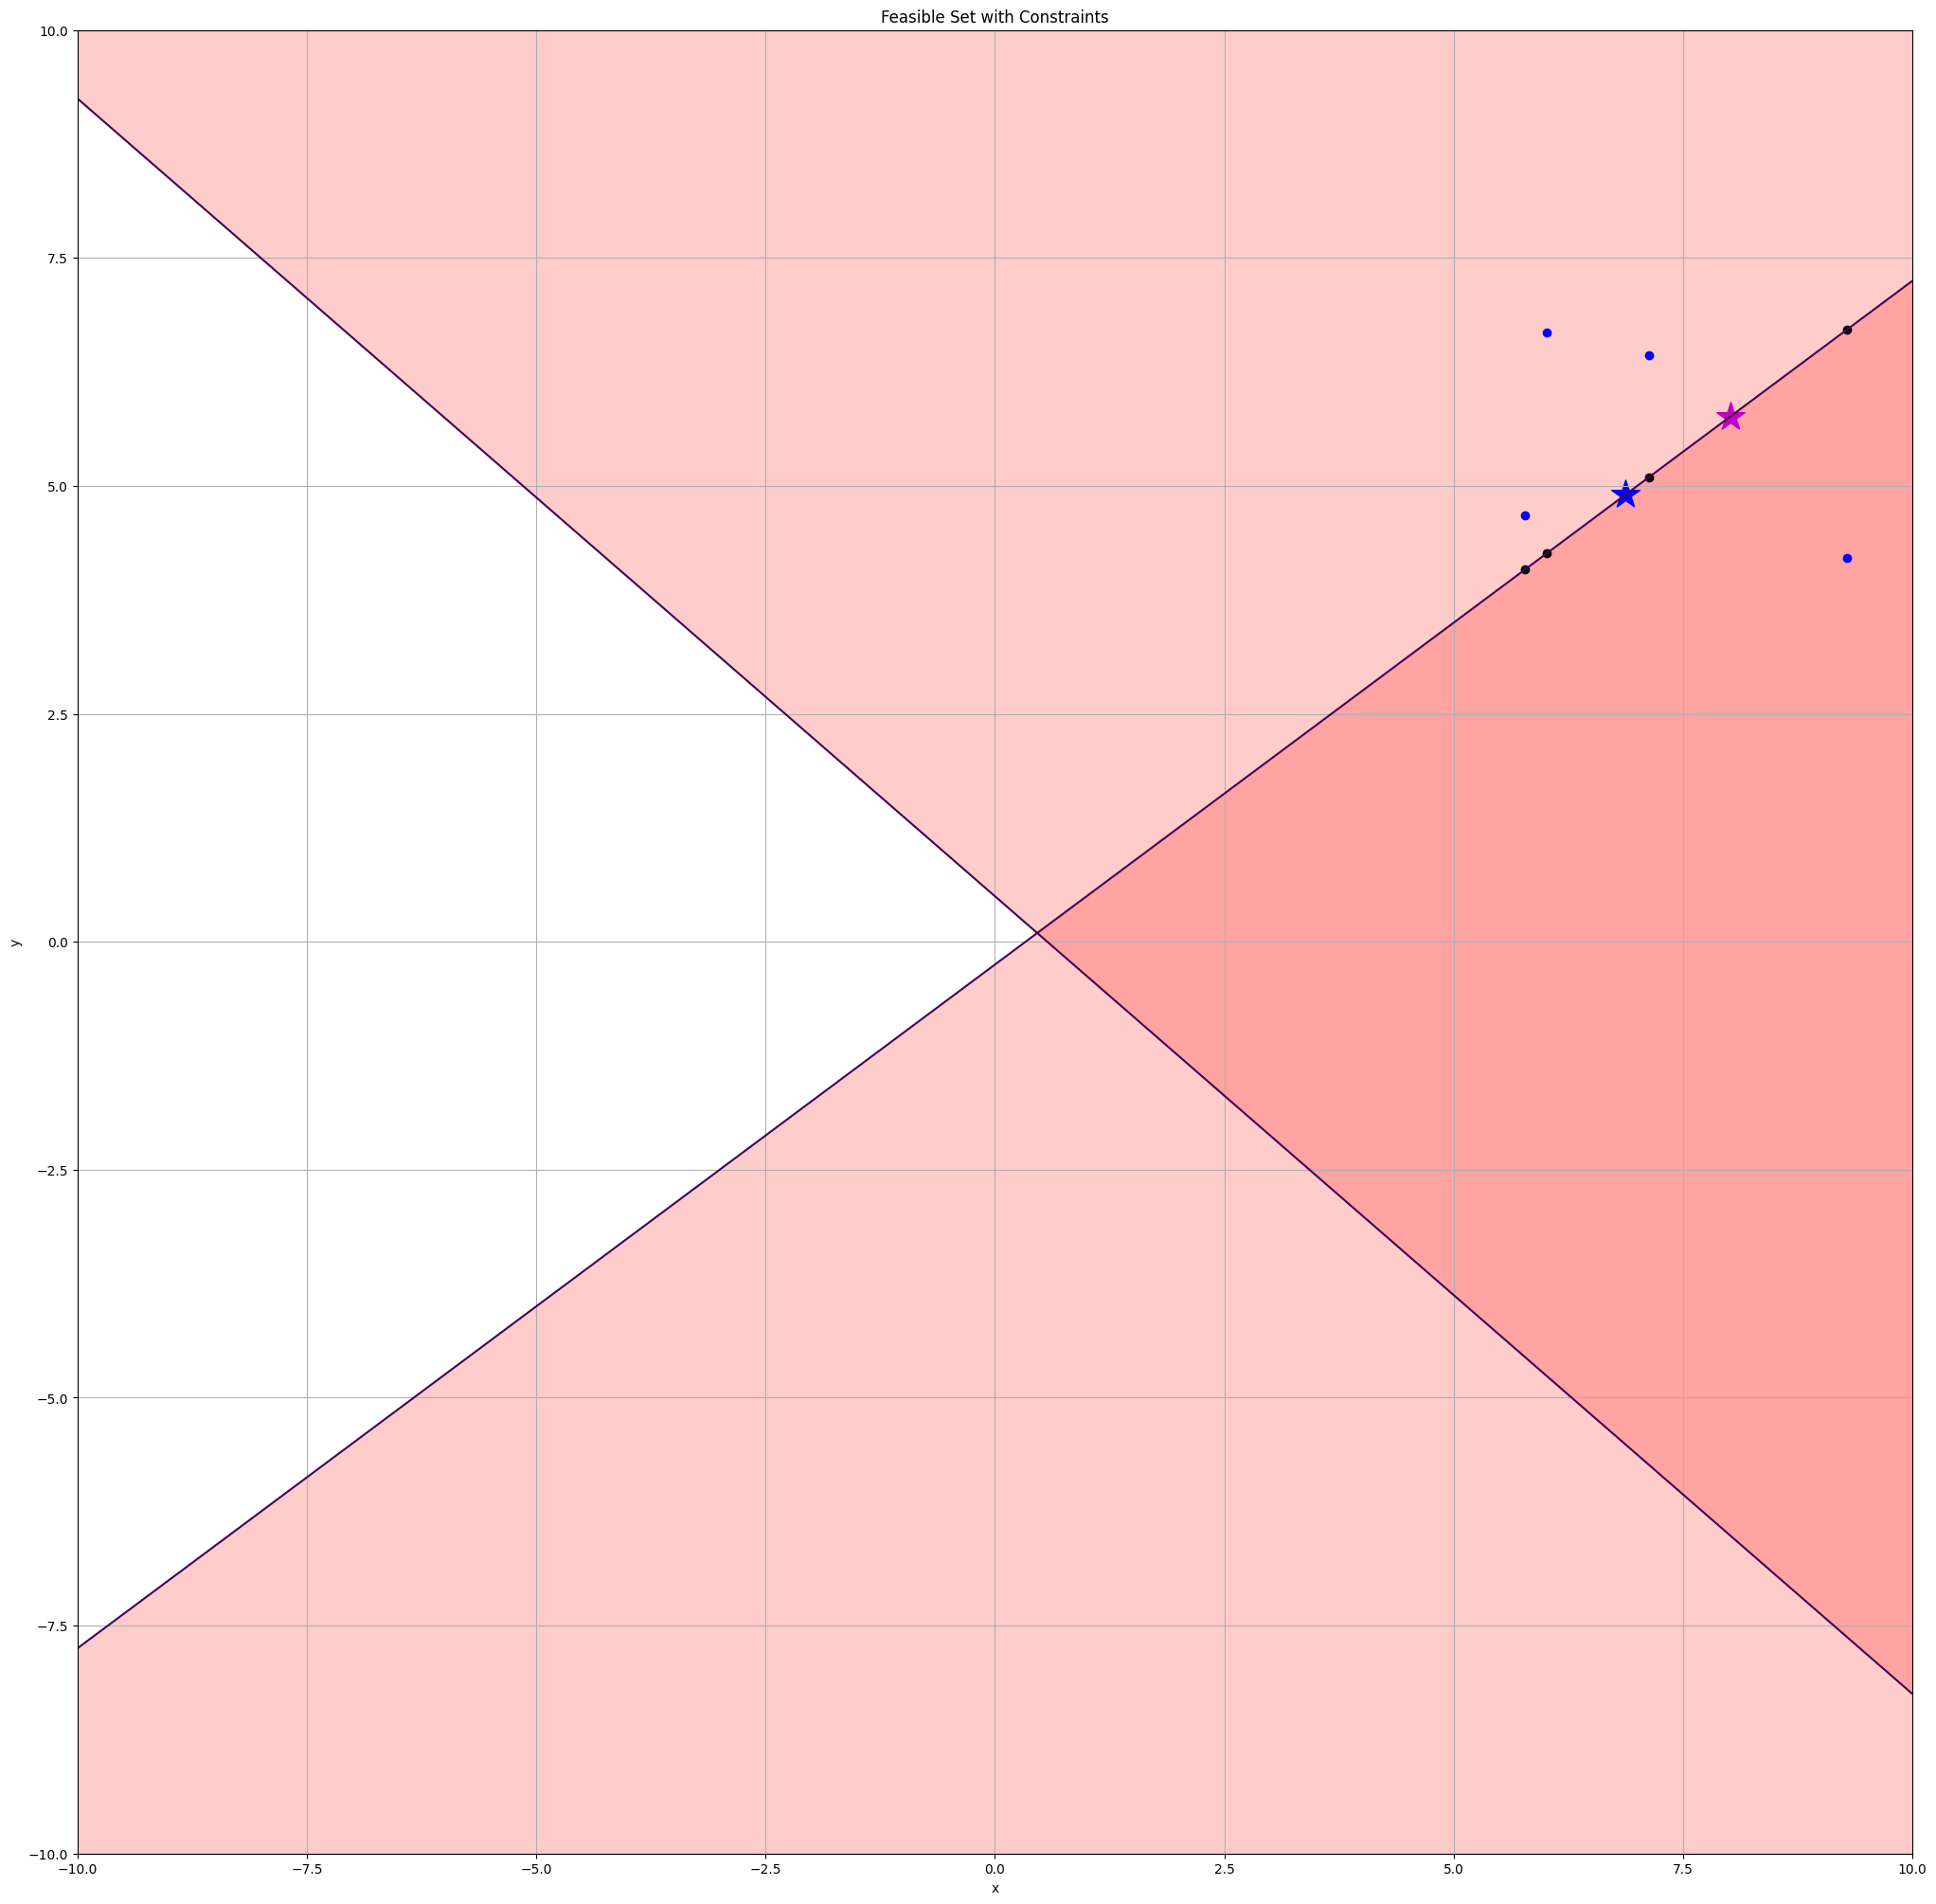

In [33]:
def plot_constraints(A, b, bounds):
    # Generate points in the feasible region
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    plt.figure(figsize=(25, 25))
    # Plot each inequality constraint as a filled contour plot
    for i in range(A.shape[0]):
        Z = A[i][0] * X + A[i][1] * Y - b[i]
        plt.contourf(X, Y, Z, levels=[-1e10, 0], colors='r', alpha=0.2)
        plt.contour(X, Y, Z, levels=[0])


    # Plot the bounds as a rectangle
    #rectangle = plt.Rectangle((bounds[0][0], bounds[1][0]), bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], edgecolor='b', fill=False)
    #plt.gca().add_patch(rectangle)

    # Plot the optimal solution
    plt.scatter(optimal_solution[0], optimal_solution[1], color='m', marker='*', s=500, label='Optimal Solution')
      # Set the size of the figure
    x_vals, y_vals = zip(*noisy_points)
    plt.scatter(x_vals, y_vals, color='blue', label='Noisy Points')
    #IL solution
    plt.scatter(Z_IL[0], Z_IL[1], color='b', marker='*', s=500, label='IL Solution')
    #IO solutions
    x_vals, y_vals = zip(*Z_IO_reshape)
    plt.scatter(x_vals, y_vals, color='black', label='IO Points')
    
        
    # Set plot labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Feasible Set with Constraints')

    # Show the plot
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    # Replace these with the constraints from the generated feasible set
    bounds = [(-10, 10), (-10, 10)]  # Example bounds for x and y
    #A = a
    plot_constraints(A, b, bounds)


## running GIL and MGIL on the example

In [34]:
def generate_random_feasible_set_sparse(dimensions, num_constraints, sparsity=0.2):
    # Generate a dense matrix with random integer values
    A = np.random.randint(-10, 10, size=(num_constraints, dimensions))
    b = np.random.randint(-5, 5, size=num_constraints)

    
    # Calculate the total number of elements in A
    total_elements = num_constraints * dimensions
    
    # Calculate the number of elements to be zeroed out to achieve the desired sparsity
    zero_elements = int(total_elements * sparsity)
    
    # Randomly choose indices to zero out
    zero_indices = np.random.choice(total_elements, zero_elements, replace=False)
    
    # Convert the indices to row and column indices
    zero_row_indices, zero_col_indices = np.unravel_index(zero_indices, (num_constraints, dimensions))
    
    # Set the selected elements to zero
    A[zero_row_indices, zero_col_indices] = 0

    # Create the bounds for each variable (bounded feasible set)
    bounds = [(0, 10) for _ in range(dimensions)]

    # Solve the linear programming problem to find a feasible solution
    result = linprog(c=[-1] * dimensions, A_ub=A, b_ub=b, bounds=bounds)
    
    # Check if the feasible set is non-empty
    if result.success:
        return A, b, bounds
    else:
        return generate_random_feasible_set_sparse(dimensions, num_constraints)

In [35]:
def check_constraints_binding(A, b, x0, tolerance=0.1):
    # Evaluate the left-hand side of the constraints at x0
    lhs = np.dot(A, x0)
    
    # Compare the left-hand side with the right-hand side (b) with a tolerance
    binding_constraints = []
    for i, constraint in enumerate(lhs):
        if np.isclose(constraint, b[i], atol=tolerance):
            binding_constraints.append(i)
    
    return binding_constraints

In [36]:
import os
import gurobipy as gp
import dill
from gurobipy import GRB
def GIL(A,b,X,acceptable,p, preffered = np.zeros(A.shape[0])):
    m1 = A.shape[0]
    n = A.shape[1]
    K = X.shape[0]
    AT = A.T
    num_var = 2 * K * n + 3 * n + m1
    e = gp.Env(empty=True)
    e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
    e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
    e.setParam('LICENSEID', 862033)
    e.start()
    m = gp.Model("IO",env=e)
    #m.Params.timeLimit = 10.0
    m.Params.OutputFlag = 0
    # Create variables
    e = m.addVars(K,n,  lb=-GRB.INFINITY, name = 'e')
    t = m.addVars(K,n,  lb=-GRB.INFINITY, name = 't')
    y = m.addVars(m1,  lb=-GRB.INFINITY, name = 'y')
    d = m.addVars(n,  lb=-GRB.INFINITY, name = 'd')
    z = m.addVars(n, lb=-GRB.INFINITY, name = 'z')
    acceptable_ind = np.where(np.array(acceptable)==1)[0]
    preffered_ind = np.where(np.array(preffered)==1)[0]
    v = m.addVars(len(acceptable_ind), vtype=GRB.BINARY)
    # Set objective:
    m.setObjective(gp.quicksum(t[k,i] for k in range (K) for i in range(n)) - 1000*gp.quicksum(v[i] for i in preffered_ind) , GRB.MINIMIZE)
    # Constraints 
    for k in range (K):
        m.addConstrs(t[k,i] >= e[k,i] for i in range(n))
        m.addConstrs(t[k,i] >= -e[k,i] for i in range(n))
        m.addConstrs(X[k,i] - e[k,i]  == z[i] for i in range(n))
    for j in range(m1):
        m.addConstr(gp.quicksum(A[j,i] * z[i] for i in range(n)) <= b[j])
    for j in acceptable_ind:
        m.addConstr(v[j]*gp.quicksum(A[j,i] * z[i] for i in range(n)) == v[j]*b[j])
    m.addConstr(gp.quicksum(v[i] for i in acceptable_ind)==p)    
    m.params.NonConvex = 2   
    m.optimize()
    print("GIL Status:", m.status)
    vars = m.getVars()
    #for i in range (n):
    #    print (vars [num_var -1 -(n-1-i)])
#     n = A.shape[1]
    Z = np.zeros (n)
    C = np.zeros (len(acceptable_ind))
    feas = (m.status == GRB.OPTIMAL)
    if feas:
        count = 0
        for V in z.values():
            Z[count] = V.X
            count += 1
        count = 0
        for V in v.values():
            C[count] = V.X #this is a binary vector indicating the binding constraints for the solution found (this is used in determining the cost vector)
            count += 1
        m.dispose()
        return Z, C
    else:
        m.dispose()
        return np.NaN, np.NaN

In [37]:
acceptable = np.ones(A.shape[0])
Z_GIL = {}
V_GIL = {}
for p in range(2):
    Z_GIL[p+1], V_GIL[p+1] = GIL(A,b,np.array(noisy_points),acceptable,p+1)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
GIL Status: 2
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
GIL Status: 2


In [38]:
V_GIL

{1: array([0., 1.]), 2: array([1., 1.])}

In [39]:
binding = check_constraints_binding(A, b, optimal_solution, tolerance=0.1)
binding

[1]

In [40]:
knowledge = 1
preffered = np.zeros(A.shape[0])
knowledge_counter = 0
for i in binding:
    if knowledge_counter < knowledge: 
        preffered[i] = 1
        knowledge_counter +=1
    else:
        break
preffered

array([0., 1.])

In [41]:
acceptable = np.ones(A.shape[0])
preffered = np.array([1,0])
Z_GIL = {}
V_GIL = {}
for p in range(2):
    Z_GIL[p+1], V_GIL[p+1] = GIL(A,b,np.array(noisy_points),acceptable,p+1,preffered)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
GIL Status: 2
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
GIL Status: 2


In [42]:
V_GIL

{1: array([ 1., -0.]), 2: array([1., 1.])}

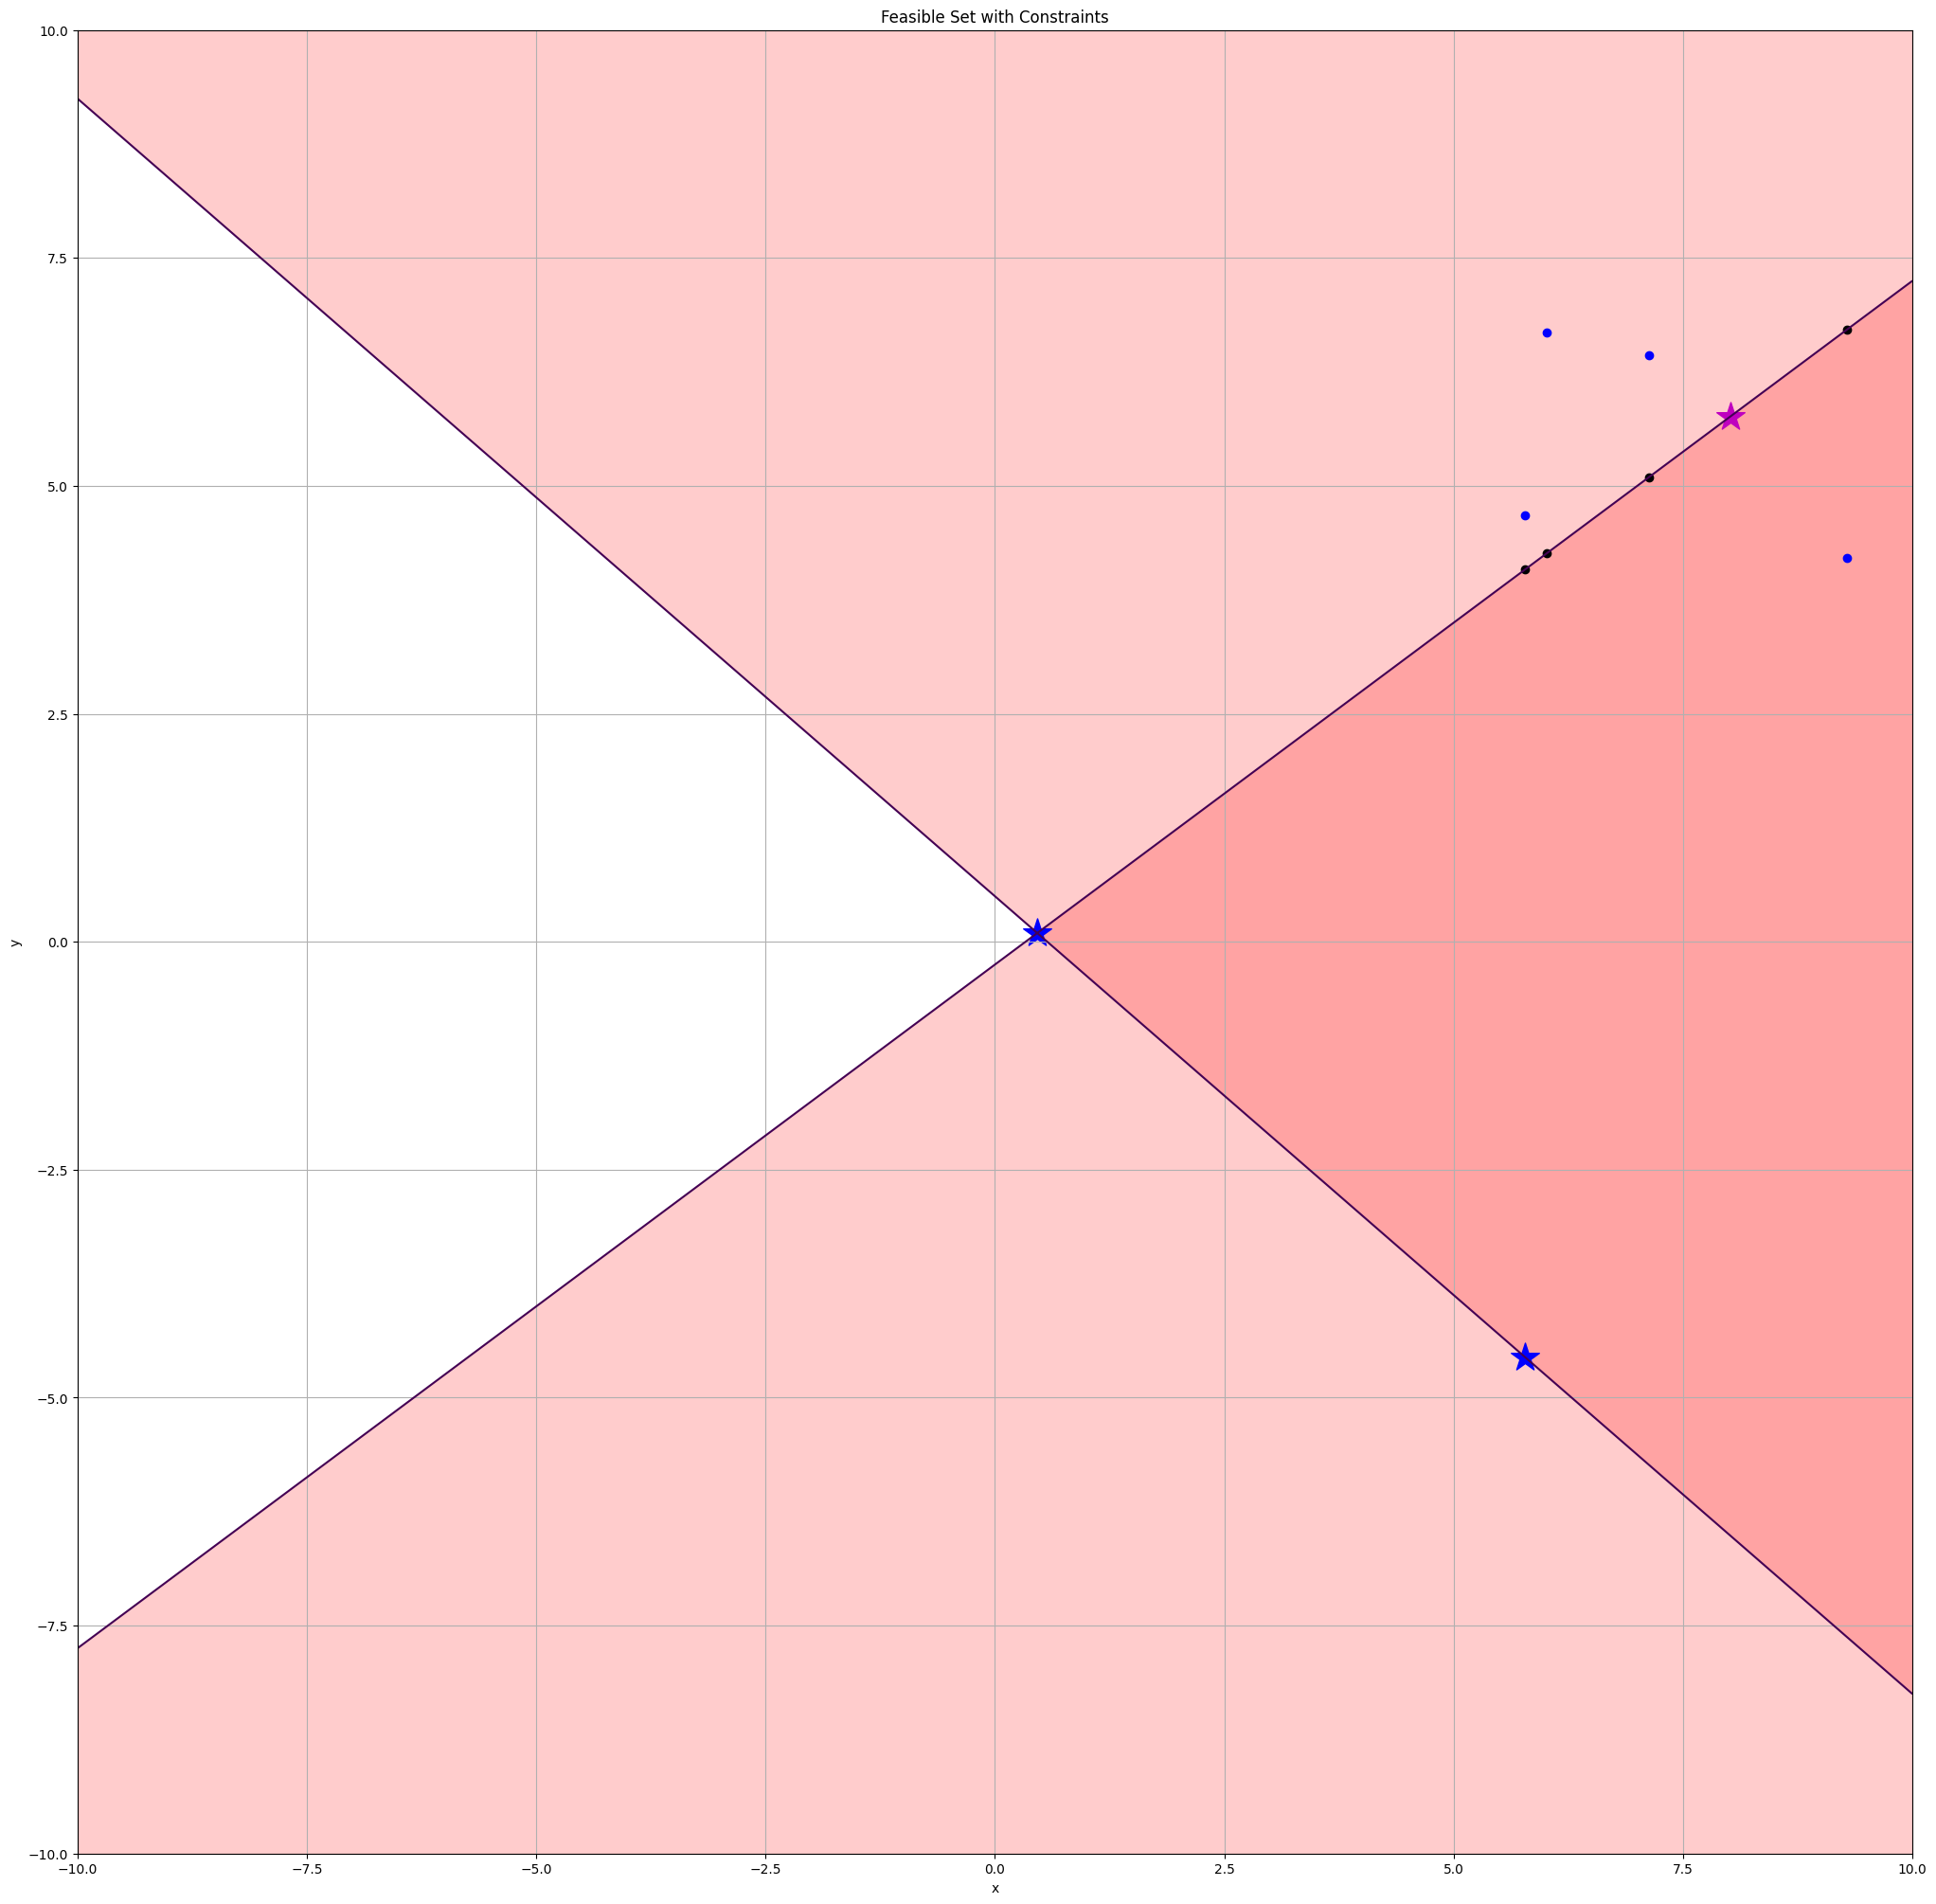

In [43]:
def plot_constraints(A, b, bounds):
    # Generate points in the feasible region
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    plt.figure(figsize=(25, 25))
    # Plot each inequality constraint as a filled contour plot
    for i in range(A.shape[0]):
        Z = A[i][0] * X + A[i][1] * Y - b[i]
        plt.contourf(X, Y, Z, levels=[-1e10, 0], colors='r', alpha=0.2)
        plt.contour(X, Y, Z, levels=[0])


    # Plot the bounds as a rectangle
    #rectangle = plt.Rectangle((bounds[0][0], bounds[1][0]), bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], edgecolor='b', fill=False)
    #plt.gca().add_patch(rectangle)

    # Plot the optimal solution
    plt.scatter(optimal_solution[0], optimal_solution[1], color='m', marker='*', s=500, label='Optimal Solution')
      # Set the size of the figure
    x_vals, y_vals = zip(*noisy_points)
    plt.scatter(x_vals, y_vals, color='blue', label='Noisy Points')
    #IL solution
    for p in range(2):
        plt.scatter(Z_GIL[p+1][0], Z_GIL[p+1][1], color='b', marker='*', s=500, label='IL Solution')
    #IO solutions
    x_vals, y_vals = zip(*Z_IO_reshape)
    plt.scatter(x_vals, y_vals, color='black', label='IO Points')
    
        
    # Set plot labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Feasible Set with Constraints')

    # Show the plot
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    # Replace these with the constraints from the generated feasible set
    bounds = [(-10, 10), (-10, 10)]  # Example bounds for x and y
    #A = a
    plot_constraints(A, b, bounds)


In [44]:
import os
import gurobipy as gp
import dill
from gurobipy import GRB
def MGIL(A,b,X,acceptable,tight,p, preffered = np.zeros(A.shape[0])):
    m1 = A.shape[0]
    n = A.shape[1]
    K = X.shape[0]
    AT = A.T
    num_var = 2 * K * n + 3 * n + m1
    e = gp.Env(empty=True)
    e.setParam('WLSACCESSID', 'aee9347f-b4d4-4058-a8c2-a0c6954ea740')
    e.setParam('WLSSECRET', '30cef1f9-9233-48a0-a138-9d092ef2ce32')
    e.setParam('LICENSEID', 862033)
    e.start()
    m = gp.Model("IO",env=e)
    #m.Params.timeLimit = 10.0
    m.Params.OutputFlag = 0
    # Create variables
    e = m.addVars(K,n,  lb=-GRB.INFINITY, name = 'e')
    t = m.addVars(K,n,  lb=-GRB.INFINITY, name = 't')
    y = m.addVars(m1,  lb=-GRB.INFINITY, name = 'y')
    d = m.addVars(n,  lb=-GRB.INFINITY, name = 'd')
    z = m.addVars(n, lb=-GRB.INFINITY, name = 'z')
    acceptable_ind = np.where(np.array(acceptable)==1)[0]
    preffered_ind = np.where(np.array(preffered)==1)[0]
    tight_ind = np.where(np.array(tight)==1)[0]
    v = m.addVars(len(acceptable_ind), vtype=GRB.BINARY)
    # Set objective:
    m.setObjective(gp.quicksum(t[k,i] for k in range (K) for i in range(n))- 1000*gp.quicksum(v[i] for i in preffered_ind), GRB.MINIMIZE)
    # Constraints 
    for k in range (K):
        m.addConstrs(t[k,i] >= e[k,i] for i in range(n))
        m.addConstrs(t[k,i] >= -e[k,i] for i in range(n))
        m.addConstrs(X[k,i] - e[k,i]  == z[i] for i in range(n))
    for j in range(m1):
        m.addConstr(gp.quicksum(A[j,i] * z[i] for i in range(n)) <= b[j])
    for j in acceptable_ind:
        m.addConstr(v[j]*gp.quicksum(A[j,i] * z[i] for i in range(n)) == v[j]*b[j])
    m.addConstr(gp.quicksum(v[i] for i in acceptable_ind)==p)
    m.addConstrs(v[i]==1 for i in tight_ind)
    m.params.NonConvex = 2   
    m.optimize()
    print("DGIL Status:", m.status)
    vars = m.getVars()
    #for i in range (n):
    #    print (vars [num_var -1 -(n-1-i)])
#     n = A.shape[1]
    Z = np.zeros (n)
    C = np.zeros (len(acceptable_ind))
    feas = (m.status == GRB.OPTIMAL)
    if feas:
        count = 0
        for V in z.values():
            Z[count] = V.X
            count += 1
        count = 0
        for V in v.values():
            C[count] = V.X
            count += 1
        m.dispose()
        return Z, C
    else:
        m.dispose()
        return np.NaN, np.NaN

In [45]:
acceptable = np.ones(A.shape[0])
Z_MGIL = {}
V_MGIL = {}
tight = []
for p in range(2):
    Z_MGIL[p+1], V_MGIL[p+1] = MGIL(A,b,np.array(noisy_points),acceptable,tight,p+1)
    tight = V_MGIL[p+1]

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
DGIL Status: 2
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
DGIL Status: 2


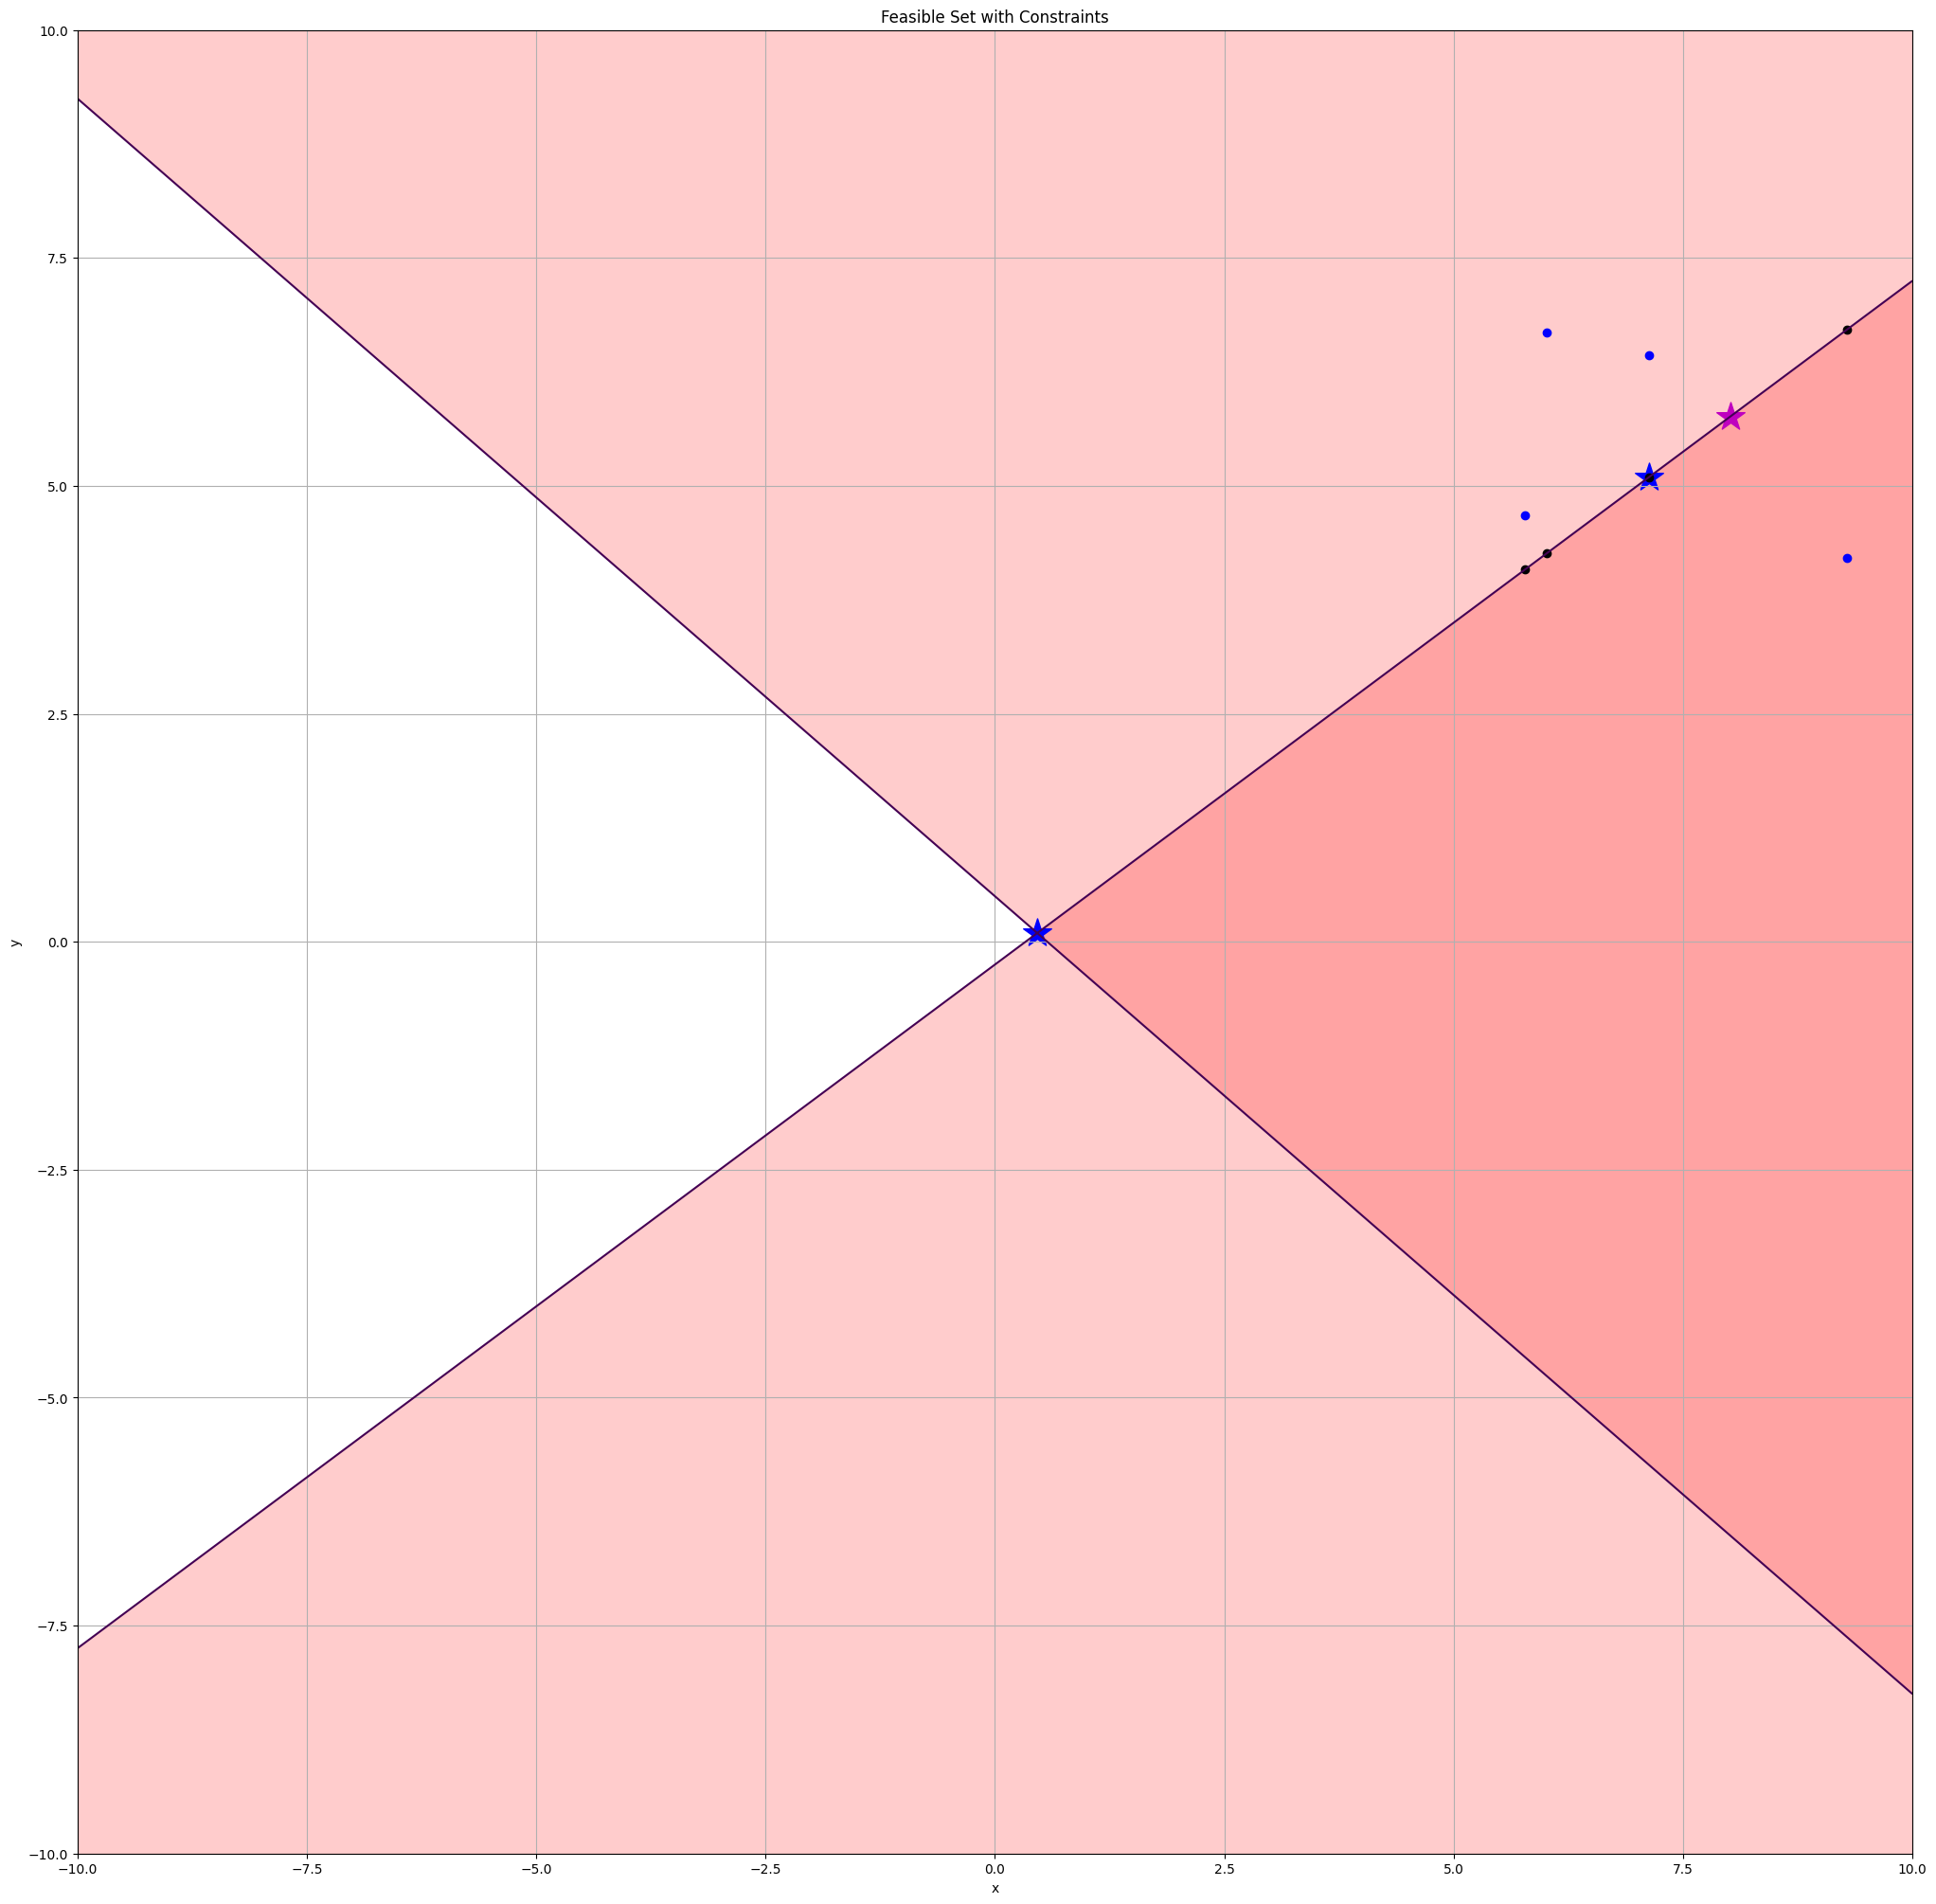

In [46]:
def plot_constraints(A, b, bounds):
    # Generate points in the feasible region
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    plt.figure(figsize=(25, 25))
    # Plot each inequality constraint as a filled contour plot
    for i in range(A.shape[0]):
        Z = A[i][0] * X + A[i][1] * Y - b[i]
        plt.contourf(X, Y, Z, levels=[-1e10, 0], colors='r', alpha=0.2)
        plt.contour(X, Y, Z, levels=[0])


    # Plot the bounds as a rectangle
    #rectangle = plt.Rectangle((bounds[0][0], bounds[1][0]), bounds[0][1] - bounds[0][0], bounds[1][1] - bounds[1][0], edgecolor='b', fill=False)
    #plt.gca().add_patch(rectangle)

    # Plot the optimal solution
    plt.scatter(optimal_solution[0], optimal_solution[1], color='m', marker='*', s=500, label='Optimal Solution')
      # Set the size of the figure
    x_vals, y_vals = zip(*noisy_points)
    plt.scatter(x_vals, y_vals, color='blue', label='Noisy Points')
    #IL solution
    for p in range(2):
        plt.scatter(Z_MGIL[p+1][0], Z_MGIL[p+1][1], color='b', marker='*', s=500, label='IL Solution')
    #IO solutions
    x_vals, y_vals = zip(*Z_IO_reshape)
    plt.scatter(x_vals, y_vals, color='black', label='IO Points')
    
        
    # Set plot labels and title
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Feasible Set with Constraints')

    # Show the plot
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    # Replace these with the constraints from the generated feasible set
    bounds = [(-10, 10), (-10, 10)]  # Example bounds for x and y
    #A = a
    plot_constraints(A, b, bounds)
